In [124]:
import numpy as np
import pandas as pd

In [133]:
class Node:
    def __init__(self, feature_index = None, threshold = None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left_ = left
        self.right_ = right
        self.value = value

class DecisionTreeClassifier:
    def __init__(self, max_depth=3):
        self.criterion = 'gini' #'entropy
        self.max_depth = max_depth
        self.min_samples_split = 0
        self.root = None
    
    def _best_split(self, X, y):
        best_split_information_gain = 0
        best_split_feature_index = None
        best_split_threshold_value = None
        for i in range(X.shape[1]):
            x = X[:, i].reshape(-1, 1)
            y = y.reshape(-1, 1)
            
            uniq_values = np.unique(x)
            if uniq_values.dtype.kind in 'bif':
                uniq_values = np.sort(x)
                threshold_candidates = (uniq_values[1:] + uniq_values[: -1])/2
            else:
                threshold_candidates = uniq_values.copy()
            
            for tcand in threshold_candidates:
                cond = x <= tcand
                lg, rg = y[cond][:, np.newaxis], y[~cond][:, np.newaxis]
                
                information_gain = self.calculate_information_gain_(lg, rg)
                if information_gain > best_split_information_gain:
                    best_split_information_gain = information_gain
                    best_split_feature_index = i
                    best_split_threshold_value = float(tcand)
        return best_split_feature_index, best_split_threshold_value, best_split_information_gain
                
    def calculate_information_value_(self, x):
        if self.criterion == 'gini':
            n = len(x)
            if n == 0:
                return 0
            pos_ = x.sum()
            neg_ = n - pos_
            return 1 - (pos_/n)**2 - (neg_/n)**2
        else:
            raise NotImplemented
    
    def calculate_information_gain_(self, labels_left, labels_rigth):
        m1 = len(labels_left)
        m2 = len(labels_rigth)
        n = m1 + m2
        
        y_ = np.vstack((labels_left, labels_rigth))
        civ_left = self.calculate_information_value_(labels_left)
        civ_right = self.calculate_information_value_(labels_rigth)
        civ_x = self.calculate_information_value_(y_)
        
        return civ_x - (m1/n*civ_left + m2/n*civ_right)
    
    def fit(self, X, y):
        if isinstance(X, (pd.DataFrame, pd.Series)):
            X = X.to_numpy()
        else:
            X = X.copy()
        if isinstance(y, (pd.DataFrame, pd.Series)):
            y = y.to_numpy()
        else:
            y = y.copy()
        self.root = self._build_tree(X, y)
        return self
    
    def _build_tree(self, X, y, depth=0):
        if len(y) == 0:
            return Node(value=None)
        if depth <= (self.max_depth - 1):
            currdepth = depth + 1
            bs_featind, bs_threshval, bs_infgain = self._best_split(X, y)
            if bs_threshval is None:
                val = np.argmax(np.bincount(y))
                return Node(value=val) #leaf
            
            cond = X[:, bs_featind] <= bs_threshval
            Xleft, Xright = X[cond], X[~cond]
            yleft, yright = y[cond], y[~cond]
            left_split_, right_split_ = self._build_tree(Xleft, yleft, currdepth), self._build_tree(Xright, yright, currdepth)
            return Node(bs_featind, bs_threshval, left_split_, right_split_) #node
        val = np.argmax(np.bincount(y))
        return Node(value=val) #leaf
    
    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        
        if x[node.feature_index] <= node.threshold:
            return self._traverse_tree(x, node.left_)
        return self._traverse_tree(x, node.right_)
    
    def predict(self, X):
        ypreds = [self._traverse_tree(x, self.root) for x in X]
        return np.array(ypreds)
    
    
    def export_graphviz(self, feature_names=None):
        """Generuje kod źródłowy dla Graphviz."""
        dot_lines = ["digraph Tree {", "node [shape=box, style=\"filled, rounded\", color=\"black\", fontname=\"helvetica\"];", "edge [fontname=\"helvetica\"];"]
        
        def add_node_to_dot(node, node_id):
            if node.value is not None:
                # Węzeł jest liściem
                dot_lines.append(f'{node_id} [label="Class: {node.value}", fillcolor="#e5f5e0"];')
            else:
                # Węzeł decyzyjny
                feat = feature_names[node.feature_index] if feature_names else f"X[{node.feature_index}]"
                label = f"{feat} <= {float(node.threshold):.2f}"
                dot_lines.append(f'{node_id} [label="{label}", fillcolor="#399de52a"];')
                
                # Połączenia do dzieci
                left_id = f"{node_id}L"
                right_id = f"{node_id}R"
                
                dot_lines.append(f'{node_id} -> {left_id} [labeldistance=2.5, labelangle=45, headlabel="True"];')
                dot_lines.append(f'{node_id} -> {right_id} [labeldistance=2.5, labelangle=-45, headlabel="False"];')
                
                add_node_to_dot(node.left_, left_id)
                add_node_to_dot(node.right_, right_id)

        add_node_to_dot(self.root, "root")
        dot_lines.append("}")
        return "\n".join(dot_lines)
        

Wygenerowano dane: (50, 5)
Rozkład klas: [18 32]


C:\Users\PC\AppData\Local\Temp\ipykernel_9728\627236219.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  best_split_threshold_value = float(tcand)


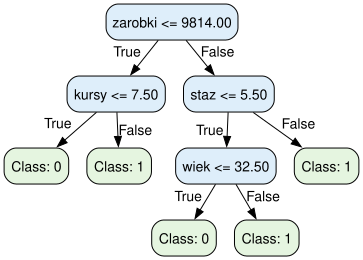

In [138]:
import numpy as np
import pandas as pd
from graphviz import Source

# Ustawiamy ziarno losowości, aby wyniki były powtarzalne
np.random.seed(42)

# 1. Generujemy 5 cech (X)
# X0: Wiek (20-70)
# X1: Zarobki (3000-20000)
# X2: Staż pracy w latach (0-40)
# X3: Wynik testu psychologicznego (0-100) - to będzie szum
# X4: Liczba ukończonych kursów (0-10)
X = np.column_stack([
    np.random.randint(20, 71, size=50),
    np.random.randint(3000, 20001, size=50),
    np.random.randint(0, 41, size=50),
    np.random.uniform(0, 100, size=50), 
    np.random.randint(0, 11, size=50)
])

# 2. Tworzymy etykiety (y) na podstawie logicznych reguł
# Przykładowo: Klasa 1 (Awans), jeśli (Zarobki > 10000 i Staż > 5) LUB (Kursy > 7)
# W pozostałych przypadkach Klasa 0
y = []
for row in X:
    zarobki = row[1]
    staz = row[2]
    kursy = row[4]
    
    if (zarobki > 10000 and staz > 5) or (kursy > 7):
        y.append(1)
    else:
        y.append(0)

y = np.array(y)

# 3. Pakujemy w DataFrame dla lepszej czytelności
feature_names = ['wiek', 'zarobki', 'staz', 'test_wynik', 'kursy']
df_X = pd.DataFrame(X, columns=feature_names)

print(f"Wygenerowano dane: {df_X.shape}")
print(f"Rozkład klas: {np.bincount(y)}")

# Teraz możesz wytrenować model
tree = DecisionTreeClassifier(max_depth=4)
tree.fit(df_X, y)

# I zwizualizować go
dot_data = tree.export_graphviz(feature_names=feature_names)
Source(dot_data)